### 🧠Answer Synthesis from Multiple Sources

✅ What Is It?
Answer synthesis from multiple sources is the process where an AI agent collects information from different retrieval tool or knowledge bases and merges that information into a single, coherent and contextually rich answer.

This is a core capability in Agentic RAG, where the system is more than just a simple retriever - it plans, retrieves and then synthesizes an answer that draws from multiple sources.

🎯 Why it's needed most real-world queries are:
- Multifaced (require multiple types of information)
- Ambiguous or incomplete (need refinement)
- Open-ended (don't map to a single document or source)

🔎 This makes retrieving from a single vector DB insufficient.

Instead, an agent that can:
- Decide what to fetch from where (retrieval planning)
- Retrieve content from multiple tools (e.g., Wikipedia, PDFs, APIs, SQL)
- Evaluate and merge that context
- Produce a single human-like response

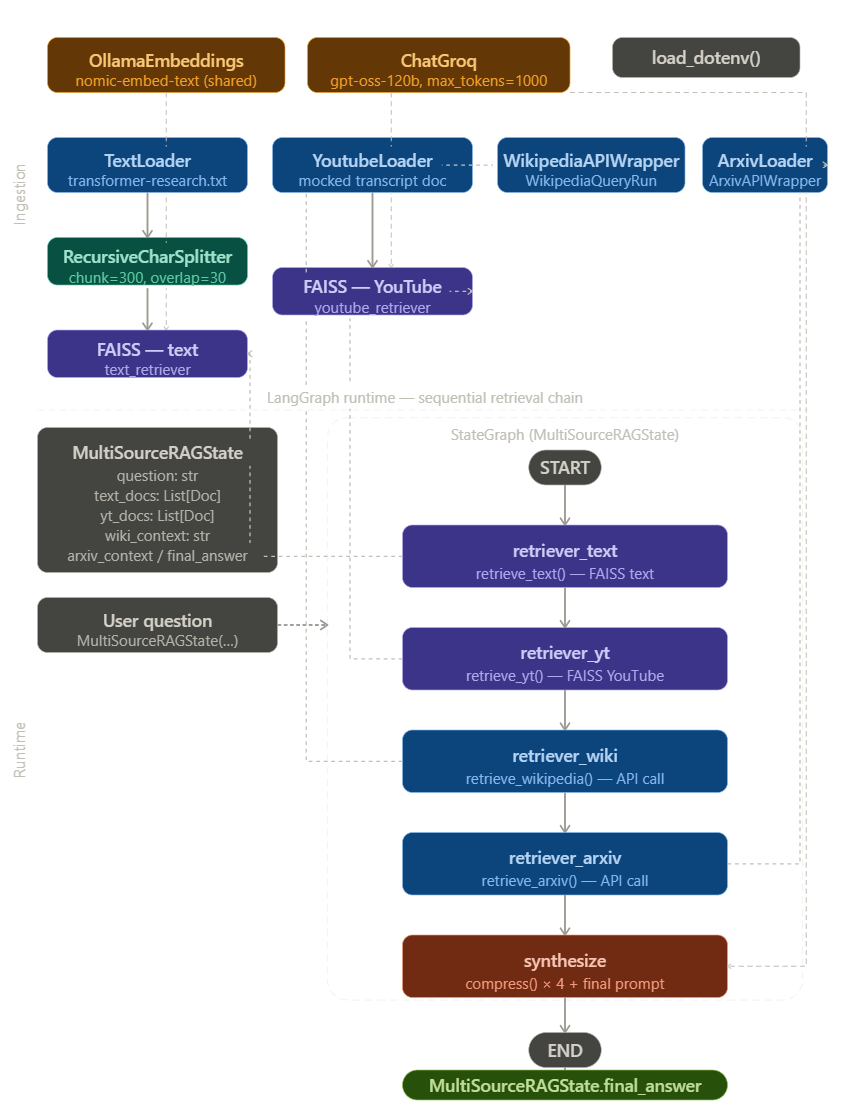

In [15]:
# ------------------------------------------------------------
# 1. Embeddings and LLM 
# ------------------------------------------------------------

from langchain_ollama.embeddings import OllamaEmbeddings
from langchain_groq import ChatGroq
import os
from dotenv import load_dotenv

load_dotenv()
os.environ['GROQ_API_KEY'] = os.getenv('groq_api_key')

embedding = OllamaEmbeddings(model='nomic-embed-text')
llm = ChatGroq(model='openai/gpt-oss-120b', max_tokens=1000)

In [16]:
# ------------------------------------------------------------
# 2. Retrievers 
# ------------------------------------------------------------

from langchain_community.document_loaders import TextLoader, YoutubeLoader, ArxivLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_classic.schema import Document
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper
from langchain_community.tools import WikipediaQueryRun, ArxivQueryRun

# Text Retriever
def load_text_retriever(file_path):
    docs = TextLoader(file_path=file_path, encoding='utf-8').load()
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=30)
    chunks = text_splitter.split_documents(docs)
    vector_db = FAISS.from_documents(chunks, embedding)
    return vector_db.as_retriever()

# Youtube Retriever
def load_youtube_retriever():
    # Mocked YouTube transcript text
    content = """
    This video explains how agentic AI systems rely on feedback loops, memory and tool use.
    It compares them to traditional pipeline-based LLMs. Temporal reasoning and autonomous tasking are emphasized.
    """
    doc = Document(page_content=content, metadata={'source': 'youtube'})
    vectorstore = FAISS.from_documents([doc], embedding)
    return vectorstore.as_retriever()

# Wikipedia Search
def wikipedia_search(query: str) -> str:
    print('🔎 Searching from Wikipedia...')
    tool = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
    return tool.invoke(query)

# ArXiv Search
def arxiv_search(query: str) -> str:
    print('📚 Searching from Arxiv...')
    results = ArxivLoader(query).load()
    return '\n\n'.join(doc.page_content for doc in results[:2]) or 'No relevant papers found'

In [17]:
# ------------------------------------------------------------
# 3. Loaders - Text file and Youtube 
# ------------------------------------------------------------

text_retriever = load_text_retriever(file_path='data/transformer-research.txt')
youtube_retriever = load_youtube_retriever()

In [18]:
# ------------------------------------------------------------
# 4. LangGraph State Definition 
# ------------------------------------------------------------

from typing import List
from pydantic import BaseModel

class MultiSourceRAGState(BaseModel):
    question: str
    text_docs: List[Document] = []
    yt_docs: List[Document] = []
    wiki_context: str = ''
    arxiv_context: str = ''
    final_answer: str = ''

In [19]:
# ------------------------------------------------------------
# 5. Nodes 
# ------------------------------------------------------------

def retrieve_text(state: MultiSourceRAGState) -> MultiSourceRAGState:
    docs = text_retriever.invoke(state.question)
    return state.model_copy(update={'text_docs': docs[:3]})

def retrieve_yt(state: MultiSourceRAGState) -> MultiSourceRAGState:
    docs = youtube_retriever.invoke(state.question)
    return state.model_copy(update={'yt_docs': docs[:2]})

def retrieve_wikipedia(state: MultiSourceRAGState) -> MultiSourceRAGState:
    result = wikipedia_search(state.question)
    return state.model_copy(update={'wiki_context': result[:2000]})

def retrieve_arxiv(state: MultiSourceRAGState) -> MultiSourceRAGState:
    result = arxiv_search(state.question)
    return state.model_copy(update={'arxiv_context': result[:2000]})

In [20]:
# ------------------------------------------------------------
# 6. Synthesize
# ------------------------------------------------------------

def compress(text):
    return llm.invoke(f"Summarize this in 3-4 lines:\n{text}").content

def synthesize_answer(state: MultiSourceRAGState) -> MultiSourceRAGState:
    context = ''
    context += '\n\n[Internal Doc]\n' +  compress('\n'.join([doc.page_content for doc in state.text_docs]))
    context += '\n\n[YouTube Transcript]\n' +  compress('\n'.join([doc.page_content for doc in state.text_docs]))
    context += '\n\n[Wikipedia]\n' + compress(state.wiki_context)
    context += '\n\n[ArXiv]\n' + compress(state.wiki_context)
    
    prompt = f"""You have retrieved relevant context from multiple sources. Now synthesize a complete and coherent answer.
    
    Question: {state.question}
    Context: {context}
    Final Answer:"""
    
    answer = llm.invoke(prompt).content.strip()
    return state.model_copy(update={'final_answer': answer})

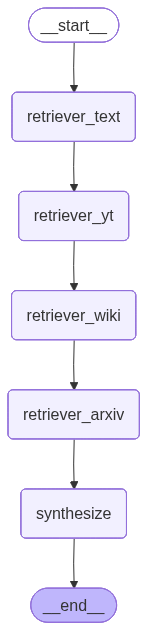

In [21]:
# ------------------------------------------------------------
# 7. LangGraph 
# ------------------------------------------------------------

from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

builder = StateGraph(MultiSourceRAGState)

builder.add_node('retriever_text', retrieve_text)
builder.add_node('retriever_yt', retrieve_yt)
builder.add_node('retriever_wiki', retrieve_wikipedia)
builder.add_node('retriever_arxiv', retrieve_arxiv)
builder.add_node('synthesize', synthesize_answer)

builder.set_entry_point('retriever_text')
builder.add_edge('retriever_text', 'retriever_yt')
builder.add_edge('retriever_yt', 'retriever_wiki')
builder.add_edge('retriever_wiki', 'retriever_arxiv')
builder.add_edge('retriever_arxiv', 'synthesize')
builder.add_edge('synthesize', END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [22]:
# ------------------------------------------------------------
# 8. Run the Agent 
# ------------------------------------------------------------

if __name__ == '__main__':
    query = 'What are transformer agents and how are they evolving in recent research?'
    state = MultiSourceRAGState(question=query)
    result = graph.invoke(state)
    
    print('\n ✅ Final Answer: \n', result['final_answer'])

🔎 Searching from Wikipedia...
📚 Searching from Arxiv...

 ✅ Final Answer: 
 **Transformer agents – a quick definition**

A *transformer agent* is a software “agent” whose core reasoning engine is a large‑scale transformer model (e.g., LLaMA‑2, GPT‑4, TinyBERT).  
Unlike a plain generative model that only produces text, a transformer‑based agent can:

1. **Perceive** – ingest prompts, documents, or sensor data.  
2. **Reason** – run the transformer’s attention‑driven inference to plan, answer, or make decisions.  
3. **Act** – invoke external tools (databases, APIs, web search, code interpreters) and feed the results back into the model, creating a closed‑loop “think‑act‑think” cycle.  

In practice, a transformer agent is often wrapped in a **framework** (e.g., LangGraph, LangChain) that orchestrates the sequence of tool calls, memory handling, and dynamic retrieval.

---

### How transformer agents are evolving in recent research

| Trend | What it is | Why it matters | Representative

In [23]:
result

{'question': 'What are transformer agents and how are they evolving in recent research?',
 'text_docs': [Document(id='4d270f7b-322c-4d09-981b-177d5d1d7123', metadata={'source': 'data/transformer-research.txt'}, page_content='Conclusion:\n\n- LLaMA2 continues to be promising for controlled chat\n- Sparse attention models are being prioritized for research\n- Dynamic RAG pipelines via LangGraph outperform static RAG'),
  Document(id='8175e6d0-00bc-4c7e-b681-5bd7a2faf4b1', metadata={'source': 'data/transformer-research.txt'}, page_content='TinyBERT:\n- Used for classification: Support ticket priority tagging\n- Evaluation: 87% F1 score, confusion in ambiguous class C\n- Works well with 2-layer FFN adapter for domain transfer\n\nAdditional Experiments:\n\n1. FlashAttention2:\n   - Integrated into LLaMA2\n   - Reduces context latency by ~50%'),
  Document(id='955909b8-bfe2-4fc0-a137-c9d085a9c5f2', metadata={'source': 'data/transformer-research.txt'}, page_content='3. Tool-augmented promptin